# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Цель: 
построить модель, которая по данным о клиенте предсказывает, уйдёт ли он в следующем месяце. Это позволит компании заранее предлагать скидки и акции именно тем, кто готов уйти, а не тратить бюджет на всех подряд.

План работы
- Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.
- Этап 2 Анализ данных (EDA): изучаем признаки, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками.
- Этап 3 Предобработка: заполняем пропуски, кодируем категории, масштабируем числа, собираем пайплайн. Делим данные 80/20 — тестовую выборку не трогаем до самого конца.
- Этап 4 Базовая модель: обучаем DummyClassifier и простую LogisticRegression с кросс-валидацией.
- Этап 5 Новые признаки: генерируем дополнительные признаки на основе уже имеющихся, проверяем помогают ли они модели.
- Этап 6 Подбор гиперпараметров: перебираем параметры LogisticRegression, сравниваем результаты в таблице, выбираем лучшую конфигурацию.
- Этап 7 Финальная модель: обучаем лучшую модель на всех тренировочных данных, замеряем качество на тестовой выборке, сохраняем модель и пайплайн через joblib.
- Этап 8 Отчёт: описываем итоговые метрики и какие признаки сильнее всего влияют на отток.

## Этап 1. Подготовка среды и библиотек
1. Установим и настроим библиотеки. 
2. Зафиксируйте `random_state`.
3. Загрузим данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`.

In [1]:
!pip install phik -q
!pip install category-encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (make_scorer, average_precision_score,roc_auc_score, f1_score, precision_score, recall_score)

random_state = 42


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [2]:
try:
    df = pd.read_csv(r'coffee_churn_dataset.csv', decimal=".")
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', decimal=".")

## Этап 2. Первичный анализ данных(EDA)

- Рассмотрим выгруженный датасет определим не влияющие на целевую переменную признаки
- Опишем целевую переменную проверим на дисбаланс
- Рассмотрим пропуски и дубликаты в столбцах, выявим варианты обработки пропусков, удалим дубликаты
- Проанализируем категориальные признаки
- Проверим данные на наличие мультиколлиниарности

### Анализ выгруженныхх данных

In [3]:
print(df.info())
print(df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

Анализ выгруженных данных:
- данные соответствуют описанию всего выгружено 10450 строк
- в каждом столбце признака есть пропуски до 10%
- нет пропусков в целевой переменной churn
- столбец days_since_last_order модет почти напрямую отражать churn следует проверить есть ли граничное количество дней без заказа после которого churn 0
- множество признаков можно заменить более обощенными

### Анализ целевой переменной(churn)

Рассмотрим распределение переменной churn

Уникальные значения:
churn
0    9821
1     629
Name: count, dtype: int64


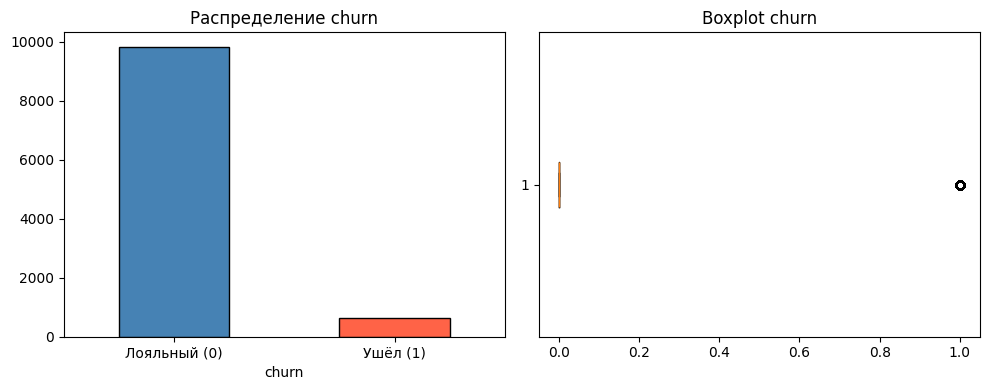

In [4]:
print("Уникальные значения:")
print(df["churn"].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["churn"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Распределение churn")
axes[0].set_xticklabels(["Лояльный (0)", "Ушёл (1)"], rotation=0)

axes[1].boxplot(df["churn"], vert=False)
axes[1].set_title("Boxplot churn")

plt.tight_layout()
plt.show()

#### Вывод:
- Целевая переменная churn бинарная: 0 — лояльный клиент, 1 — ушедший
- Классы сильно несбалансированы: ушедших клиентов 6%
- Из-за дисбаланса accuracy не несет смысла 
- Используем PR AUC как основную метрику она устойчива к дисбалансу и фокусируется именно на классе 1
- При обучении LogisticRegression обязательно ставим class_weight="balanced" это искусственно увеличит вес ушедших клиентов при обучении

### Обработка пропусков 

Рассмотрим количество в абсолютном и относительном значении в каждом столбце

In [5]:
for col in df.columns:
    missing = df[col].isna().sum()
    print(f"{col}: пропусков {missing} ({missing / len(df) * 100:.2f}%)", "\n")

user_id: пропусков 0 (0.00%) 

days_since_last_order: пропусков 945 (9.04%) 

order_frequency_month: пропусков 600 (5.74%) 

order_frequency_week: пропусков 388 (3.71%) 

avg_order_value: пропусков 583 (5.58%) 

median_order_value: пропусков 831 (7.95%) 

total_spent_last_month: пропусков 294 (2.81%) 

total_spent_last_week: пропусков 944 (9.03%) 

discount_usage_rate: пропусков 397 (3.80%) 

last_coffee_type: пропусков 258 (2.47%) 

preferred_roast: пропусков 116 (1.11%) 

milk_preference: пропусков 668 (6.39%) 

seasonal_menu_tried: пропусков 989 (9.46%) 

coffee_bean_origin: пропусков 682 (6.53%) 

last_drink_size: пропусков 504 (4.82%) 

subscription_status: пропусков 938 (8.98%) 

app_opens_per_week: пропусков 896 (8.57%) 

notifications_enabled: пропусков 537 (5.14%) 

review_rating_last_10: пропусков 693 (6.63%) 

review_rating_last_1: пропусков 857 (8.20%) 

app_crashes_last_month: пропусков 721 (6.90%) 

seasons: пропусков 679 (6.50%) 

days_since_last_promo: пропусков 731 (7.

Рассмотрим сколько строк теряем при прямом удалении

In [6]:
df_withdrop = df.dropna()
drop = len(df) - len(df_withdrop)
print(f"удалено {drop} значений ({drop / len(df) * 100:.2f}%)", "\n")

удалено 8171 значений (78.19%) 



Судя по количеству удаленных большинство строк содержат минимум 1 пропуск. Терять подобное количество данных недопустимо метод dropna применяем только в краййнем случае 

<h5> Выводы по анализу пропусков и их обработки</h5>

<ul>
  <li>
    В датасете присутствуют пропуски почти во всех признаках, при этом их доля достигает значений до 10% на столбец.
  </li>
  <li>
    Прямое удаление строк с пропусками приводит к потере 78% сторк, это недопустимо для дальнейшего анализа и построения модели.
  </li>
  <li>
    Пропуски распределены по разным признакам и строкам, поэтому большинство пользователей имеют хотя бы одно отсутствующее значение.
  </li
  <li>
    Для числовых признаков, отражающих поведение пользователей и их финансовую активность, можно использовать заполнение медианой.
  </li>
  <li>
    Для категориальных признаков решение аполнение значением "Unknown" или модой
  </li>

  <li>
    Для бинарных признаков нужно использовать наиболее частое значение.
  </li>
</ul>

### Обработка дубликатов

- приведем все значения в lower_case и сделаем проверку явных дубликатов
- рассмотрим дубликаты без id клиента 

In [7]:
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.lower()

duplicates_count = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates_count}")
df_duplicates = df[df.duplicated()]
df_duplicates

cols_without_id = df.drop(columns=["user_id"])
duplicates_no_id_count = cols_without_id.duplicated().sum()
print(f"Дубликатов без user_id: {duplicates_no_id_count}")
df_duplicates_no_id = df[cols_without_id.duplicated()]

Полных дубликатов строк: 0
Дубликатов без user_id: 414


##### Вывод 
найденно 414 поных дубликатов без user_id(это могут быть как дуюликаты так и уникальные значения) в дальнейшем проверим как отреагирует модель на удаление этих дубликатов

### Обработка категориальных данных

#### Рассмотрим сколько уникальных значений содержат категориальные типы длля определения метода кадировки
-  One-Hot Encoding заключён в том, что каждое возможное значение признака превращается в новую колонку с бинарным флагом. 
- Target Encoding название категории заменяется числом, рассчитанным на основе значений целевой переменной для этой категории (например, средним).

In [8]:
cat_cols = ["last_coffee_type", "preferred_roast", "milk_preference",        
            "coffee_bean_origin", "last_drink_size", "subscription_status",    
            "seasons", "phone_type", "geo_location"]

binary_cols = ["seasonal_menu_tried", "notifications_enabled", "coffee_preference_change"]

print("Категориальные:")
print(cat_cols)
print("Бинарные признаки")
print(binary_cols, "\n")

for col in cat_cols:
    n_unique = df[col].nunique()
    n_missing = df[col].isna().sum()
    print(f"{col}: уникальных={n_unique}, пропусков={n_missing} ({n_missing/len(df)*100:.2f}%) \n")

Категориальные:
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']
Бинарные признаки
['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change'] 

last_coffee_type: уникальных=3, пропусков=258 (2.47%) 

preferred_roast: уникальных=3, пропусков=116 (1.11%) 

milk_preference: уникальных=6, пропусков=668 (6.39%) 

coffee_bean_origin: уникальных=6, пропусков=682 (6.53%) 

last_drink_size: уникальных=3, пропусков=504 (4.82%) 

subscription_status: уникальных=4, пропусков=938 (8.98%) 

seasons: уникальных=4, пропусков=679 (6.50%) 

phone_type: уникальных=3, пропусков=336 (3.22%) 

geo_location: уникальных=100, пропусков=110 (1.05%) 



<h5>One-Hot Encoding</h5>
<ul>
  <li><b>last_coffee_type</b> - 3 значения (arabica, robusta, blend), порядка нет</li>
  <li><b>preferred_roast</b> - 3 значения (light, medium, dark), порядка нет</li>
  <li><b>milk_preference</b> - 6 значений (whole, oat, almond, skim, none, soy), порядка нет</li>
  <li><b>coffee_bean_origin</b> - 6 значений (страны), порядка нет</li>
  <li><b>seasons</b> - 4 значения (spring, summer, autumn, winter), линейного порядка нет</li>
  <li><b>phone_type</b> - 3 значения (android, ios, web), порядка нет</li>
</ul>

<h5>Ordinal Encoding</h5>
<ul>
  <li><b>last_drink_size</b> - 3 значения с явным порядком: small → medium → large</li>
  <li><b>subscription_status</b> - 4 значения с явным порядком: none → basic → pro → premium</li>
</ul>

<h5>Target Encoding</h5>
<ul>
  <li><b>geo_location</b> - 100 уникальных значений. Заменяем регион на churn rate этого региона. </li>
</ul>

<h5>Кодирование не требуется</h5>
<ul>
  <li><b>seasonal_menu_tried</b>, <b>notifications_enabled</b>, <b>coffee_preference_change</b> — бинарные признаки, уже представлены как 0.0 / 1.0</li>
</ul>

#### Обработка выбросов распределение данных

count    9505.000000
mean        4.394214
std         4.858757
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        40.000000
Name: days_since_last_order, dtype: float64
Выбросы:
Количество: 561
Процент: 5.9
Границы: -6.5 13.5
Первые 5 выбросов выше верхней границы [14. 14. 14. 14. 14.]
5 максимальных значений [36. 37. 37. 38. 40.]


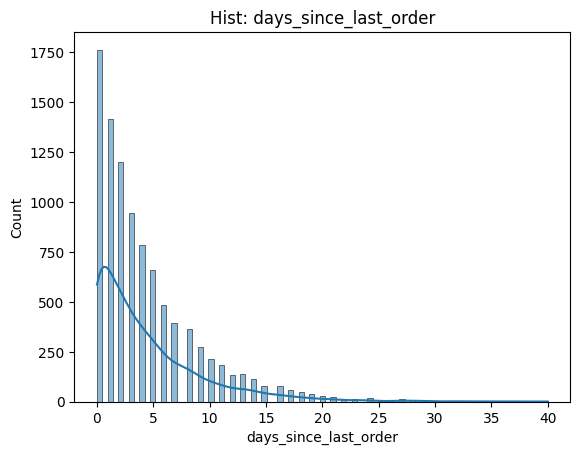

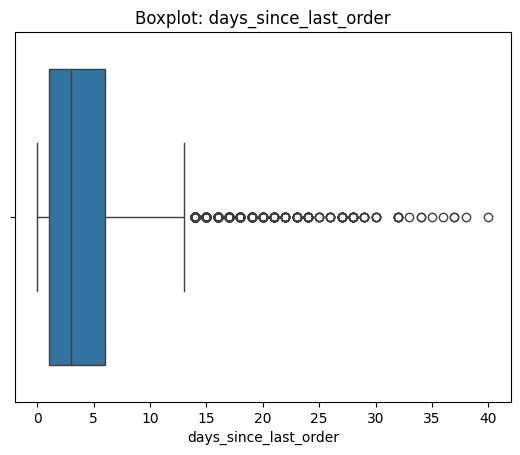

count    9850.000000
mean        4.025666
std         2.826144
min         0.011046
25%         1.937767
50%         3.381094
75%         5.439363
max        27.389318
Name: order_frequency_month, dtype: float64
Выбросы:
Количество: 302
Процент: 3.07
Границы: -3.31 10.69
Первые 5 выбросов выше верхней границы [10.69255128 10.70889664 10.71733381 10.71773382 10.71773382]
5 максимальных значений [18.94150512 19.3475154  19.76216234 20.4351911  27.38931753]


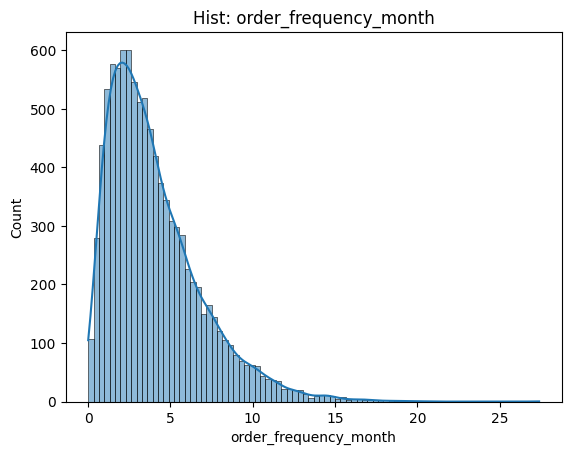

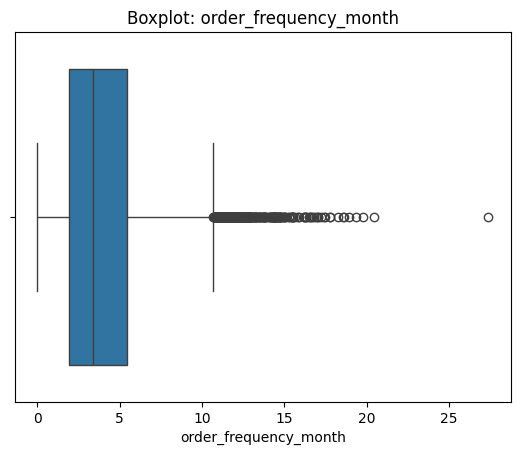

count    10062.000000
mean         0.930686
std          0.657261
min         -0.169131
25%          0.445185
50%          0.784839
75%          1.262350
max          6.302624
Name: order_frequency_week, dtype: float64
Выбросы:
Количество: 298
Процент: 2.96
Границы: -0.78 2.49
Первые 5 выбросов выше верхней границы [2.49309863 2.49482312 2.50066958 2.50210679 2.50263339]
5 максимальных значений [4.44864724 4.49142834 4.53931032 4.7606084  6.30262417]


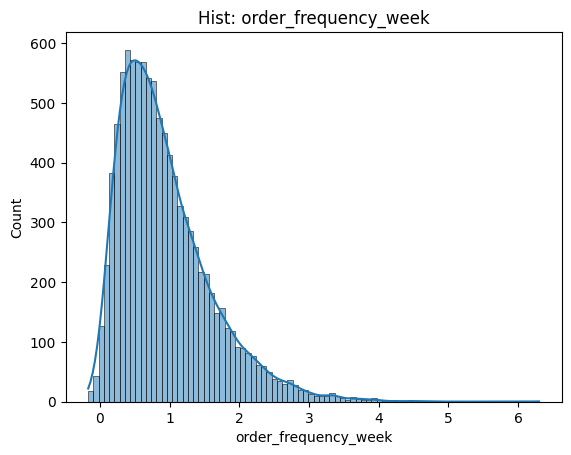

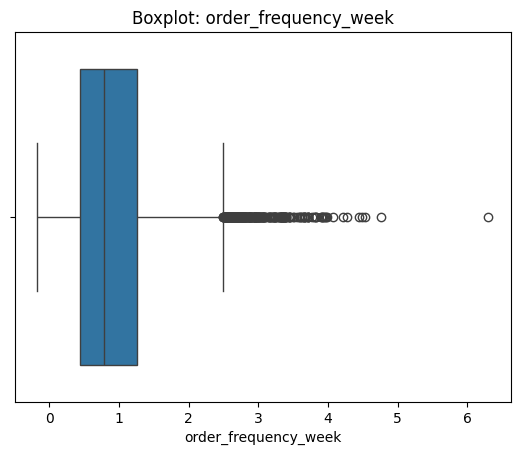

count    9867.000000
mean     1063.741207
std       707.713396
min       -32.075932
25%       552.898663
50%       898.643524
75%      1406.332153
max      5901.965278
Name: avg_order_value, dtype: float64
Выбросы:
Количество: 326
Процент: 3.3
Границы: -727.25 2686.48
Первые 5 выбросов выше верхней границы [2686.91243687 2689.14071389 2692.4145482  2695.25544131 2696.58507893]
5 максимальных значений [5337.57099122 5382.27892445 5542.53157027 5703.15607523 5901.96527775]


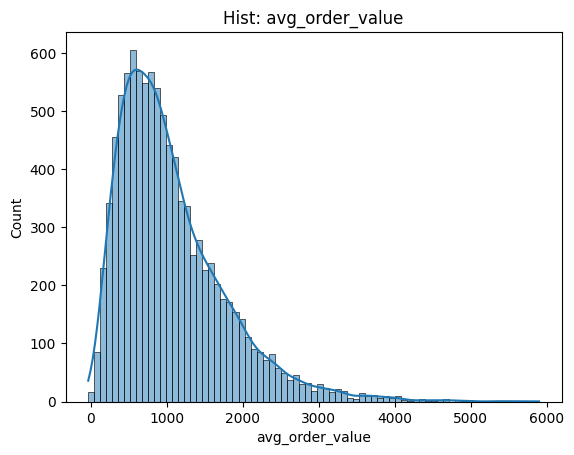

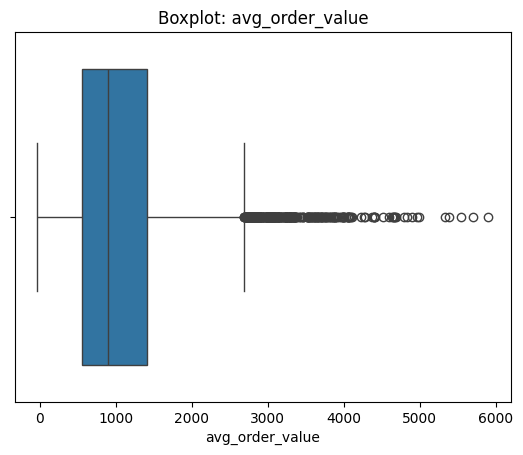

count    9619.000000
mean      452.651500
std       258.657571
min       -10.353340
25%       262.908598
50%       406.456818
75%       590.418070
max      2189.101644
Name: median_order_value, dtype: float64
Выбросы:
Количество: 225
Процент: 2.34
Границы: -228.36 1081.68
Первые 5 выбросов выше верхней границы [1082.92740415 1083.10498496 1083.10498496 1084.97203012 1086.86314875]
5 максимальных значений [1752.69910425 1815.42703449 1831.9462176  1895.87714967 2189.1016442 ]


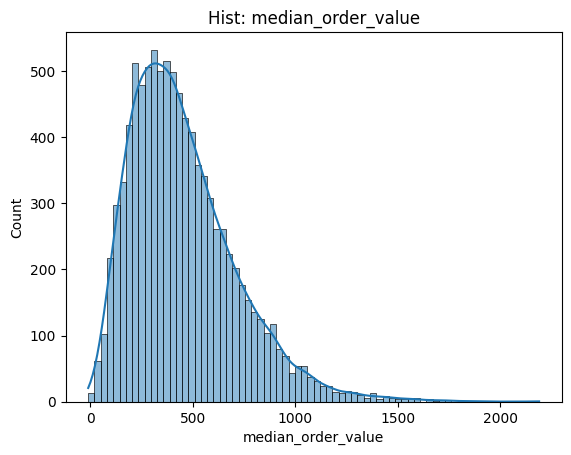

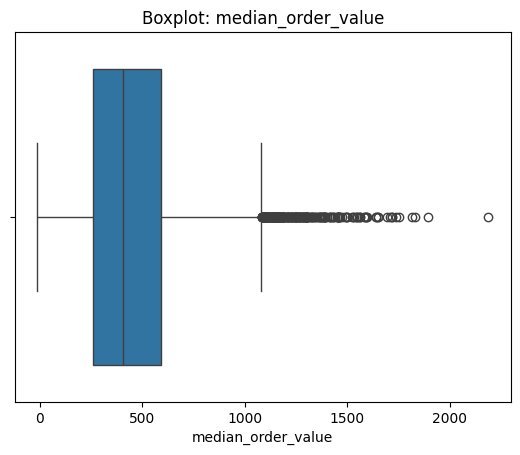

count    10156.000000
mean      1946.132979
std       2370.619590
min        -43.716463
25%        629.680382
50%       1300.409757
75%       2481.650495
max      79298.849570
Name: total_spent_last_month, dtype: float64
Выбросы:
Количество: 594
Процент: 5.85
Границы: -2148.27 5259.61
Первые 5 выбросов выше верхней границы [5263.32364968 5265.57887214 5269.12692286 5274.80209286 5275.89527687]
5 максимальных значений [32205.06633292 34431.64264734 36871.73179534 37965.68450245
 79298.84957032]


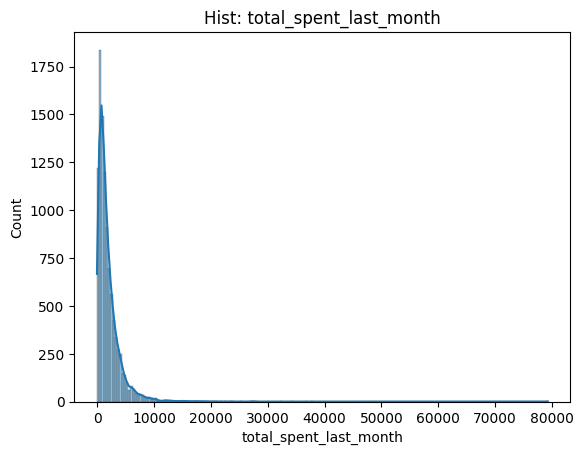

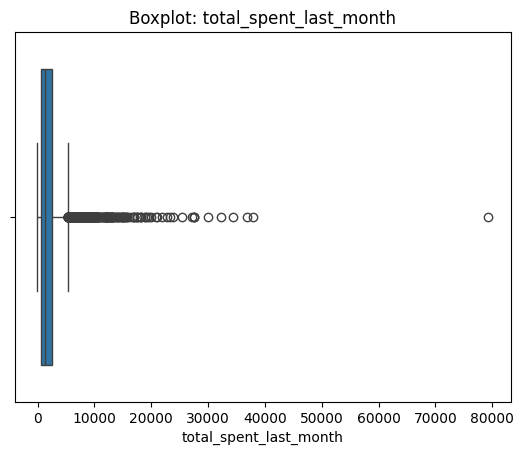

count    9506.000000
mean      413.004760
std       445.634902
min     -2290.559468
25%       136.565833
50%       288.277327
75%       549.699420
max      8615.988952
Name: total_spent_last_week, dtype: float64
Выбросы:
Количество: 565
Процент: 5.94
Границы: -483.13 1169.4
Первые 5 выбросов выше верхней границы [1169.4370077  1170.45180468 1170.6409672  1171.30372731 1171.70426638]
5 максимальных значений [4742.89808691 4742.89808691 4771.88596067 4910.58024022 8615.98895189]


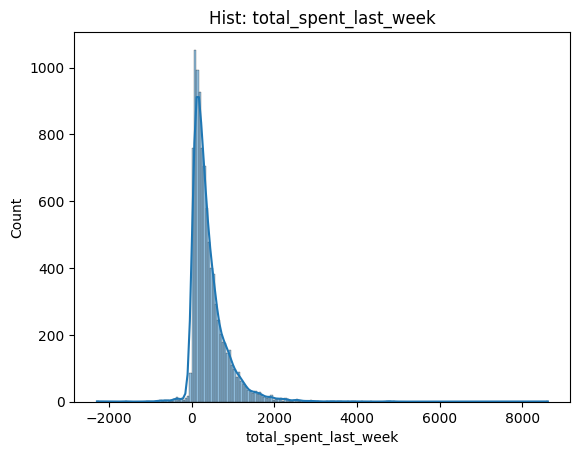

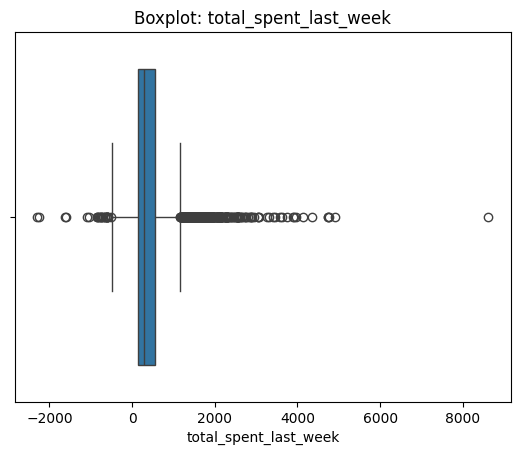

count    10053.000000
mean         0.284446
std          0.158735
min          0.002162
25%          0.159884
50%          0.264583
75%          0.387056
max          0.887301
Name: discount_usage_rate, dtype: float64
Выбросы:
Количество: 70
Процент: 0.7
Границы: -0.18 0.73
Первые 5 выбросов выше верхней границы [0.72835715 0.72857144 0.73002521 0.73043583 0.73058242]
5 максимальных значений [0.83599305 0.83694892 0.85468946 0.85483319 0.88730125]


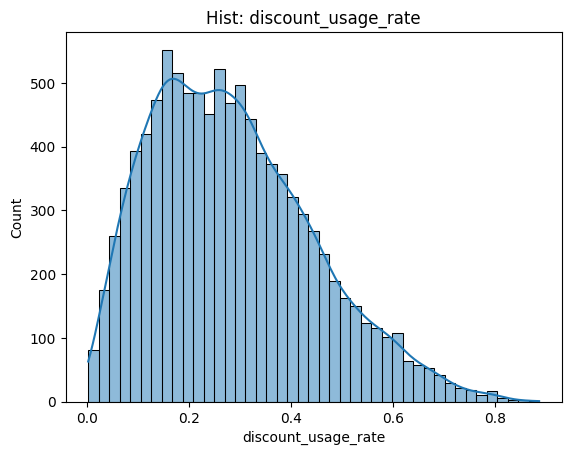

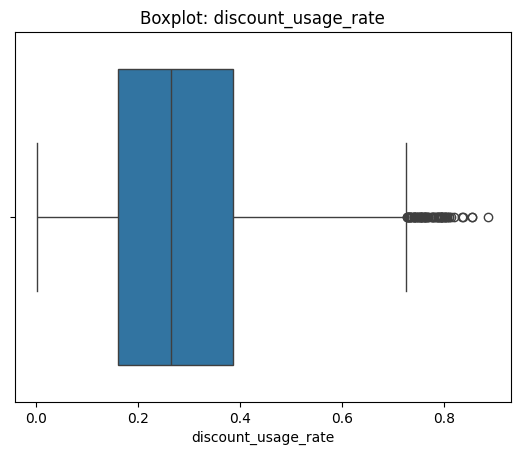

count    9554.000000
mean       11.330895
std        14.528887
min         0.000000
25%         6.313628
50%         9.228383
75%        12.726649
max       224.587876
Name: app_opens_per_week, dtype: float64
Выбросы:
Количество: 355
Процент: 3.72
Границы: -3.31 22.35
Первые 5 выбросов выше верхней границы [22.35219676 22.43818742 22.49064863 22.50260924 22.55085087]
5 максимальных значений [202.04019399 202.90564109 206.72295158 224.42671805 224.5878758 ]


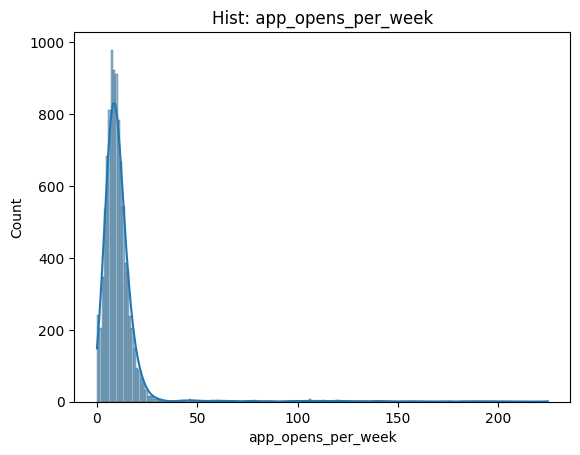

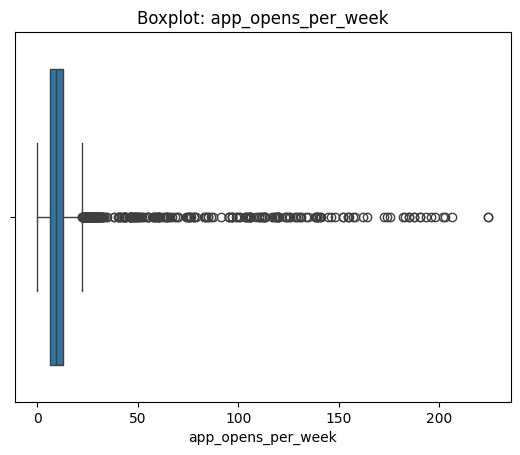

count    9757.000000
mean        4.206709
std         0.782212
min         1.415526
25%         3.675543
50%         4.203555
75%         4.717292
max         7.384425
Name: review_rating_last_10, dtype: float64
Выбросы:
Количество: 89
Процент: 0.91
Границы: 2.11 6.28
Первые 5 выбросов выше верхней границы [6.28301884 6.28301884 6.2883635  6.29406935 6.3030552 ]
5 максимальных значений [7.01864387 7.02055181 7.02055181 7.08449775 7.38442478]


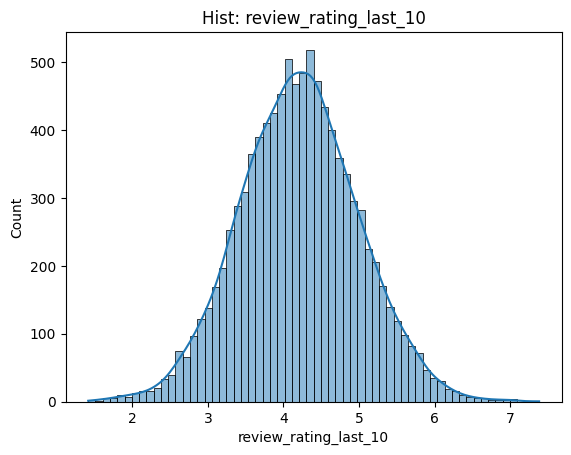

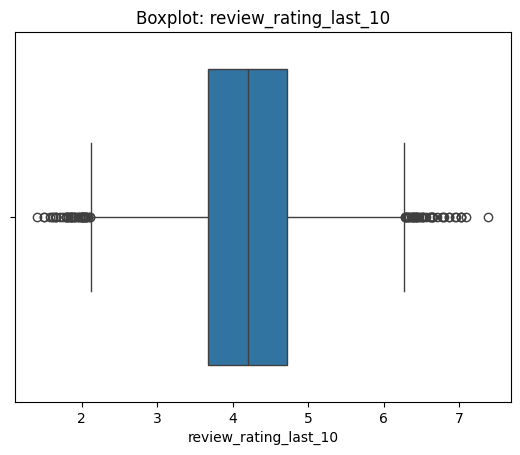

count    9593.000000
mean        4.022460
std         1.207883
min        -0.897000
25%         3.214157
50%         3.990032
75%         4.845225
max         8.558443
Name: review_rating_last_1, dtype: float64
Выбросы:
Количество: 72
Процент: 0.75
Границы: 0.77 7.29
Первые 5 выбросов выше верхней границы [7.29936248 7.32049815 7.32414487 7.36388451 7.37914064]
5 максимальных значений [7.95389974 8.13778957 8.26141572 8.52840514 8.55844256]


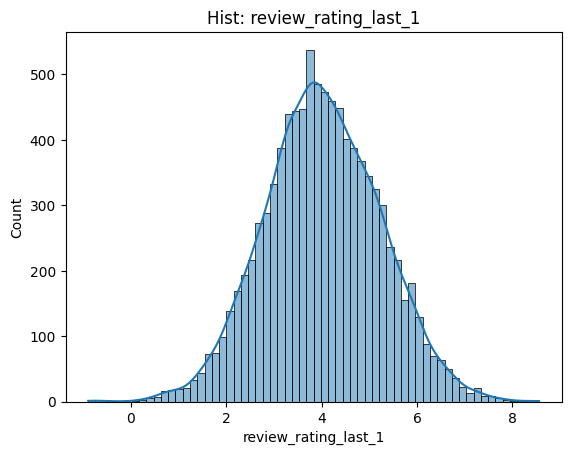

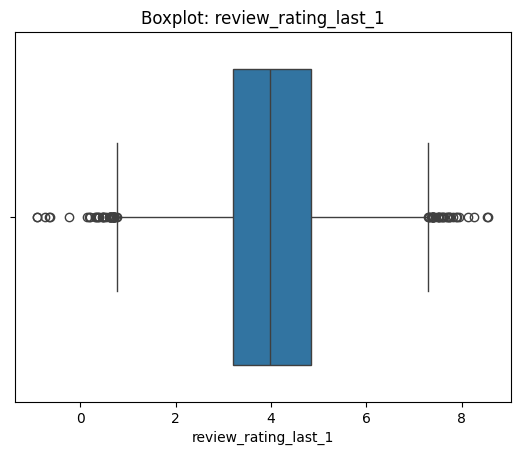

count    9729.000000
mean        1.013362
std         1.010342
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: app_crashes_last_month, dtype: float64
Выбросы:
Количество: 7
Процент: 0.07
Границы: -3.0 5.0
Первые 5 выбросов выше верхней границы [6. 6. 6. 6. 6.]
5 максимальных значений [6. 6. 6. 6. 7.]


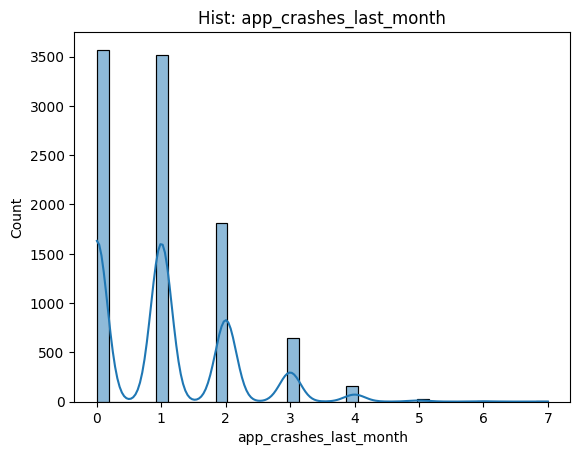

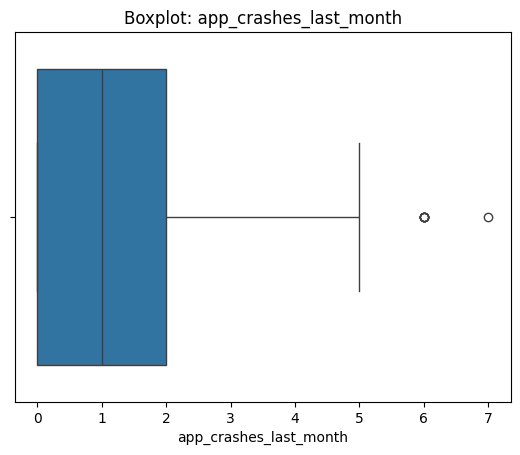

count    9719.000000
mean       14.554584
std        15.308869
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max       140.000000
Name: days_since_last_promo, dtype: float64
Выбросы:
Количество: 526
Процент: 5.41
Границы: -20.0 44.0
Первые 5 выбросов выше верхней границы [45. 45. 45. 45. 45.]
5 максимальных значений [112. 115. 120. 131. 140.]


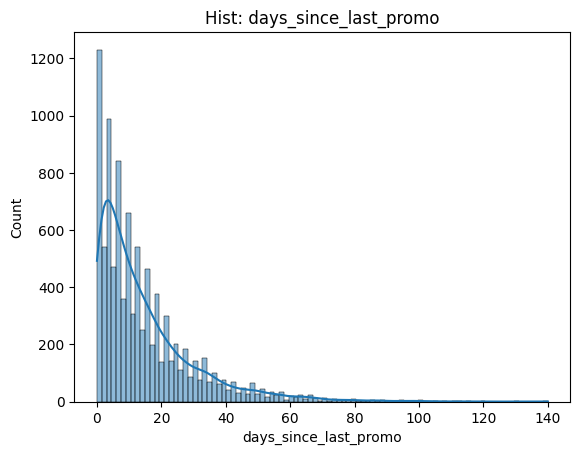

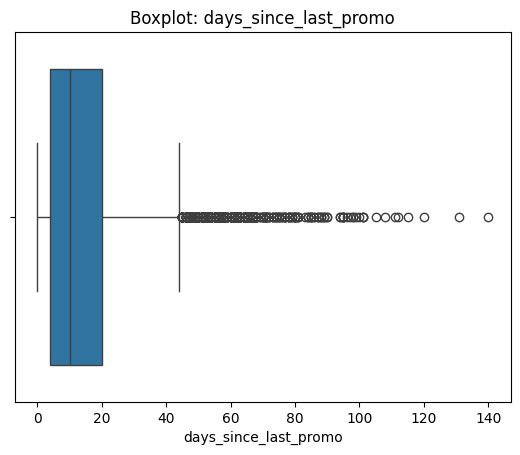

In [9]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers)/len(data)*100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы", high_outliers.head(5).values)
    print("5 максимальных значений", high_outliers.tail(5).values)
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()
    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()
num_cols = [
    "days_since_last_order",
    "order_frequency_month",
    "order_frequency_week",
    "avg_order_value",
    "median_order_value",
    "total_spent_last_month",
    "total_spent_last_week",
    "discount_usage_rate",
    "app_opens_per_week",
    "review_rating_last_10",
    "review_rating_last_1",
    "app_crashes_last_month",
    "days_since_last_promo",
]

for col in num_cols:
    data_review(df, col)

<h4>Выводы по анализу выбросов</h4>

<ul>
  <li><b>days_since_last_order</b> - 5.9% выбросов, максимум 40 дней при границе 13.5. Клиент без заказа 40 дней почти наверняка ушёл - реальное поведение, не ошибка.</li>

  <li><b>order_frequency_month</b> - 3.07% выбросов, максимум 27 заказов при границе 10.7. Значения реалистичны (активный клиент).</li>

  <li><b>order_frequency_week</b> - 2.96% выбросов, максимум 6.3 при границе 2.49. Согласуется с частотой месячных заказов</li>

  <li><b>avg_order_value</b> - 3.3% выбросов, максимум 5900 руб при границе 2686. Реальные крупные заказы.</li>

  <li><b>median_order_value</b> - 2.34% выбросов, максимум 2189 руб при границе 1081. Согласуется с avg_order_value.</li>

  <li><b>total_spent_last_month</b> - 5.85% выбросов, максимум 79 298 руб при границе 5259. Экстремальные значения (79k) — вероятно производственные заказы.</li>

  <li><b>total_spent_last_week</b> - 5.94% выбросов, максимум 8615 руб при границе 1169. Аналогично трате в месяц.</li>

  <li><b>app_opens_per_week</b> - 3.72% выбросов, максимум 224 открытия при границе 22.4. 224 открытия в неделю - это 32 раза в день, скорее всего ошибка следует рассмотреть внимательнее.</li>

  <li><b>days_since_last_promo</b> - 5.41% выбросов, максимум 140 дней при границе 44. Возможное значение. </li>
</ul>

<h5>Оставить без изменений</h5>
<ul>
  <li><b>discount_usage_rate</b> - 0.7% выбросов, значения в диапазоне [0, 1] по смыслу. Максимум 0.887.</li>

  <li><b>app_crashes_last_month</b> - 0.07% выбросов, максимум 7 крашей. Редкое, но реальное явление. Трогать не нужно.</li>
</ul>

<h5>отрицательные значения</h5>
<ul>
  <li><b>order_frequency_week</b> min = -0.17. Частота не может быть отрицательной — ошибка данных. Заменить на 0 при предобработке.</li>

  <li><b>avg_order_value</b> min = -32 руб. Средний чек не может быть отрицательным. Заменить на 0 или медиану при предобработке.</li>

  <li><b>median_order_value</b> min = -10 руб. Аналогично. Заменить на 0.</li>

  <li><b>total_spent_last_month</b> min = -43 руб. Аналогично. Заменить на 0.</li>

  <li><b>total_spent_last_week</b> min = -2290 руб. Значение аномально большое по модулю возможно возврат или ошибка.</li>
  <li><b>review_rating_last_1</b> min = -0.897. Оценка не может быть отрицательной. Заменить на 0.</li>
</ul>

Невозможные значения заполним медианой, пока установим  nan так как не было разделения для подсчета медианы

In [10]:
invalid_cols = [
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'review_rating_last_1'
]

for col in invalid_cols:
    df.loc[df[col] < 0, col] = np.nan

Денежные признаки и рейтинг заполним 0(возможен возврат)

In [11]:
money_cols = ['total_spent_last_month', 'total_spent_last_week']

for col in money_cols:
    df.loc[df[col] < 0, col] = 0

Пользователи с большим количеством заходов

In [12]:
more100 = df[df['app_opens_per_week'] > 100]

print("Количество пользователей:", len(more100))
more100_sorted = more100.sort_values(['app_opens_per_week'], ascending=False).reset_index(drop=True)
for i in range(0, 80, 8):
    print(more100_sorted.loc[i, 'app_opens_per_week'])

Количество пользователей: 83
224.587875800987
190.74423922499813
175.40397560830388
154.765219117138
140.86998293458137
134.02761038606045
124.40785992818526
119.51875076021147
112.72410801367148
106.05012213848325


Нет четкого порога значит это реальные необычные пользователи методом логарифма можно сгладить правый хвост

### Проверка на мультиколлиниарность создание phik матрицы

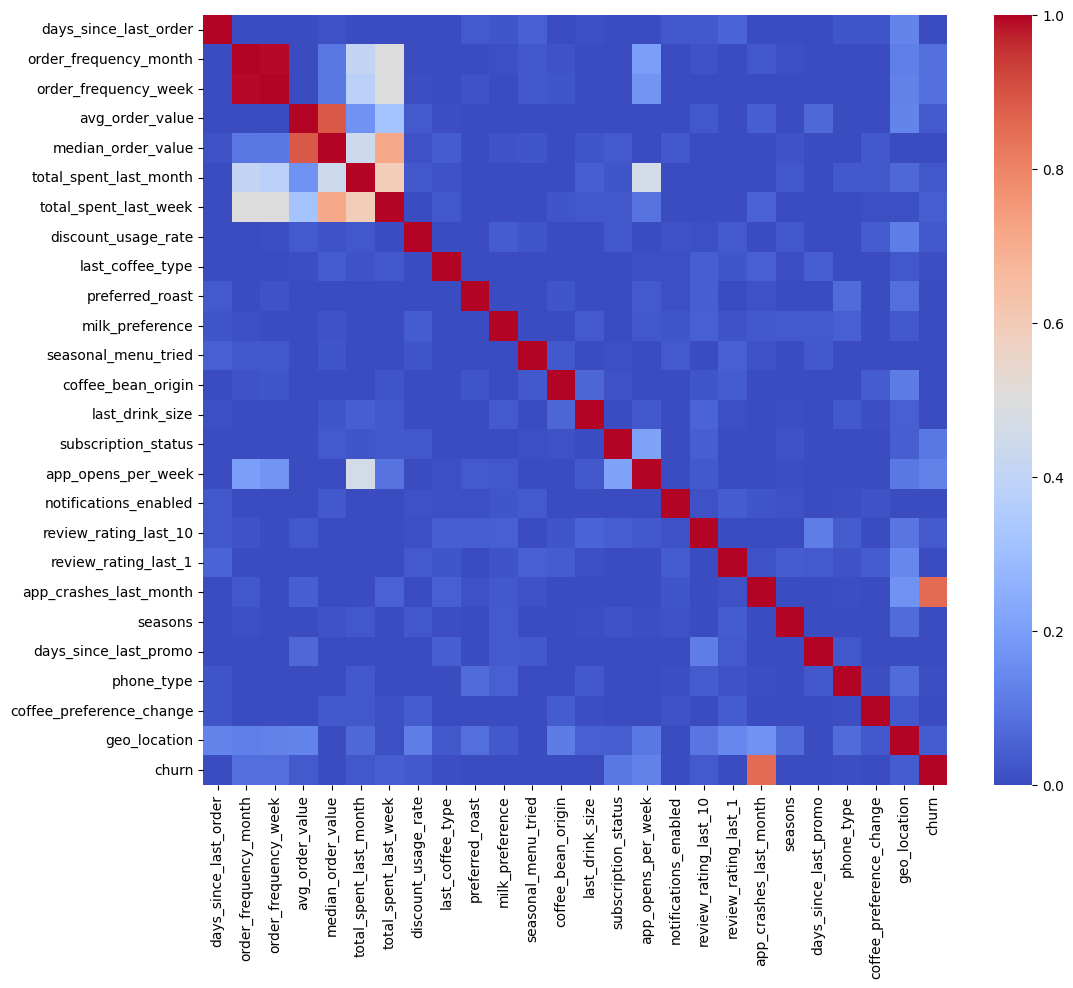

In [13]:
df = df.drop(columns=["user_id"])
interval_cols = [
    "days_since_last_order",
    "order_frequency_month",
    "order_frequency_week",
    "avg_order_value",
    "median_order_value",
    "total_spent_last_month",
    "total_spent_last_week",
    "discount_usage_rate",
    "app_opens_per_week",
    "review_rating_last_10",
    "review_rating_last_1",
    "app_crashes_last_month",
    "days_since_last_promo"
]
phik_matrix = df.phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(12, 10))
sns.heatmap(phik_matrix, cmap="coolwarm")
plt.show()

Многие признаки никак не связаны друг с друнгом проверим еще раз наиболее связанные между сабой судя по матрице

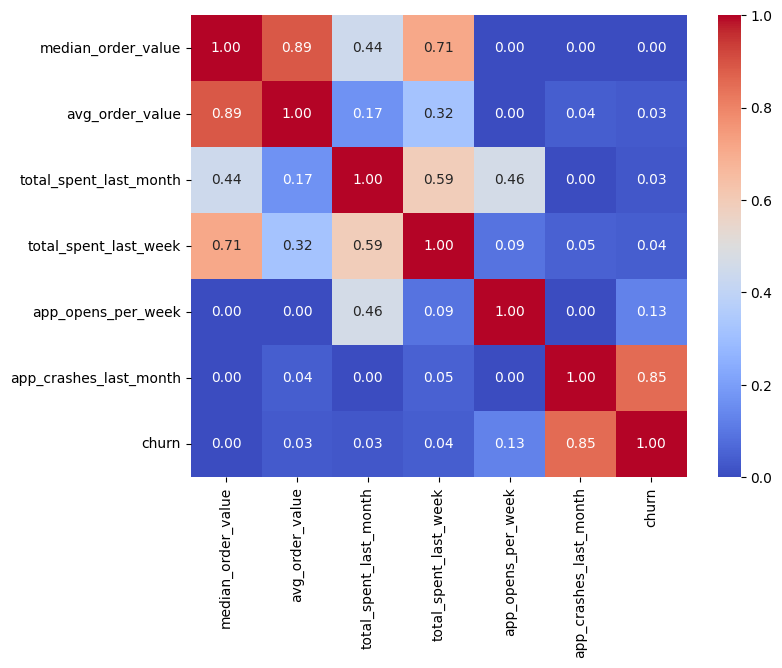

In [14]:
selected_features = [
    "median_order_value",
    "avg_order_value",
    "total_spent_last_month",
    "total_spent_last_week",
    "app_opens_per_week",
    "app_crashes_last_month",
    "churn"
]
df_selected = df[selected_features]
phik_selected = df_selected.phik_matrix(interval_cols=selected_features[:-2])
plt.figure(figsize=(8,6))
sns.heatmap(phik_selected, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

<h3>Вывод по матрице корреляции:</h3>
<h4>Связь с целевой переменной (churn)</h4>
<ul>
  <li><b>app_crashes_last_month</b> - 0.854 (очень сильная связь)</li>
</ul>

<ul>
  <li>Высокая связь между:</li>
  <ul>
    <li>avg_order_value median_order_value (0.89)</li>
    <li>total_spent_last_week total_spent_last_month (0.61)</li>
    <li>order_frequency_week order_frequency_month = 0.99</li>
  <li>Признаки несут одинаковую информацию и могут быть объединены или сокращены.</li>
  </ul>
</ul>

<ul>
  <li>Выделены сильные корреляционные связи</li>
  <li>Наиболее значимый фактор оттока - стабильность приложения (crashes)</li>
  <li>Гипотеза о пороге в "days_since_last_order" после которог churn 0 не подтвердилась. Связь не обнаружена</li>
</ul>


## Этап 3. Предобработка данных

1. Разделим данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используем для обучения и кросс-валидации модели.

2. Предобработаем данные. Создадим
   - пайплайн, который обработает пропуски и выбросы.
     
   - пайплайн, который обработает категориальные признаки.

   - пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



### Разделим данные в пропорции 80 к 20. 20% данных отложим для теста

In [15]:
def prepare_pipeline(num_cols, cat_cols, ordinal_cols=None, target_cols=None, missing_num="median",
                     scaling="standard", missing_cat="most_frequent", encode="onehot", collinear_cols=None):
    if collinear_cols is None:
        collinear_cols = []
    if ordinal_cols is None:
        ordinal_cols = []
    if target_cols is None:
        target_cols = []
    
    num_cols = [c for c in num_cols if c not in collinear_cols]
    cat_cols = [c for c in cat_cols if c not in collinear_cols]
    target_cols = [c for c in target_cols if c not in collinear_cols]
    ordinal_cols = [(c, cats) for c, cats in ordinal_cols if c not in collinear_cols]
    
    num_steps = [("imputer", SimpleImputer(strategy=missing_num))]
    if scaling == "standard":
        num_steps.append(("scaler", StandardScaler()))
    elif scaling == "minmax":
        num_steps.append(("scaler", MinMaxScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [("imputer", SimpleImputer(strategy=missing_cat))]
    if encode == "onehot":
        cat_steps.append(("encoder", OneHotEncoder(handle_unknown="ignore", sparse=False)))
    cat_pipe = Pipeline(cat_steps)

    transformers = [("num", num_pipe, num_cols),
                    ("cat", cat_pipe, cat_cols),]

    for col, categories in ordinal_cols:
        ordinal_pipe = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OrdinalEncoder(categories=[categories]))])
        
        transformers.append((f"ord_{col}", ordinal_pipe, [col]))

    if target_cols:
        target_pipe = Pipeline([
            ("encoder", TargetEncoder(handle_unknown="value", handle_missing="value"))])
        transformers.append(("target", target_pipe, target_cols))

    preprocessor = ColumnTransformer(transformers, remainder="drop")
    return preprocessor

In [16]:
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 'total_spent_last_month', 'total_spent_last_week',    
            'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month',
            'days_since_last_promo', 'seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change',]

cat_cols = ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'seasons', 'phone_type']

ordinal_cols = [('last_drink_size',     ['small', 'medium', 'large']),
                ('subscription_status', ['none', 'basic', 'pro', 'premium'])]

target_cols = ['geo_location']  

collinear_cols = ['order_frequency_week', 'median_order_value']  

preprocessor = prepare_pipeline(
    num_cols=num_cols,
    cat_cols=cat_cols,
    ordinal_cols=ordinal_cols,
    target_cols=target_cols,
    collinear_cols=collinear_cols,
    scaling='standard'
)

X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed  = preprocessor.transform(X_test)

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

## Этап 4. Обучение модели

1. Обучим базовую версию модели.
   - Используем для этого простые статистические модели.

   - Используем кросс-валидацию для обучения модели.

2. Посчитаем метрики, поставленные в задаче. Опираясь на них, сделаем вывод о качестве модели.

In [ ]:
def model_test(name, model, X, y, cv_splits=5):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    pr_aucs, roc_aucs, f1s, precisions, recalls = [], [], [], [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        pr_aucs.append(average_precision_score(y_val, y_proba))
        roc_aucs.append(roc_auc_score(y_val, y_proba))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))

    return {"model": name,
            "pr_auc": round(np.mean(pr_aucs), 4),
            "pr_auc_std": round(np.std(pr_aucs), 4),
            "roc_auc": round(np.mean(roc_aucs), 4),
            "f1": round(np.mean(f1s), 4),
            "precision": round(np.mean(precisions), 4),
            "recall": round(np.mean(recalls),  4),}

def dummy_test(X, y, cv_splits=5):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    model = DummyClassifier(strategy="stratified", random_state=42)
    pr_aucs, roc_aucs, f1s, precisions, recalls = [], [], [], [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        
        pr_aucs.append(average_precision_score(y_val, y_proba))
        roc_aucs.append(roc_auc_score(y_val, y_proba))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))
    return {
        "model": "Dummy_stratified",
        "pr_auc": round(np.mean(pr_aucs), 4),
        "pr_auc_std": round(np.std(pr_aucs), 4),
        "roc_auc": round(np.mean(roc_aucs), 4),
        "f1": round(np.mean(f1s), 4),
        "precision": round(np.mean(precisions), 4),
        "recall": round(np.mean(recalls), 4),
    }

In [ ]:
models = {
    "LogReg_default":  LogisticRegression(random_state=42, max_iter=1000),
    "LogReg_balanced": LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
}

results = [model_test(name, model, X_train_transformed, y_train) for name, model in models.items()]
results.append(dummy_test(X_train_transformed, y_train))

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
print(results_df)

- Модель LogisticRegression оказалась лучше случайного DummyClassifier с PR AUC = 0.06, в то время как LogisticRegression PR AUC = 0.67 и ROC-AUC = 0.92. Это подтверждает что признаки несут информацию об оттоке.
- LogReg_default PR AUC (0.67) и высокий Precision (0.77) из клиентов помеченных как уходящие 77% действительно уходят. Однако Recall 0.43 - модель пропускает каждого второго реально уходящего клиента. Модели с class_weight="balanced" Recall = 0.86 но Precision 0.28-0.29 - большинство клиентов получивших предложение не собирались уходить.
- Далее идет генерация новых признаков и подбор гиперпараметров, что должно улучшить PR AUC и найти баланс между Precision и Recall в соответствии с требованиями заказчика.

## Этап 5. Создание новых признаков

Для отпимизации модели следует добавить новые признаки для описания нелинейоного поведения:
- spend_per_order трата на заказ отражает возможности клиента
- week_month_ratio отношение месячных и недельных трат показывает активность клиента(ближе к 1 - недельная активность ближе к 0.25 постоянная активность)
- crashes_per_open за сколько открытий выходит ошибка показывает качество приложения
- crashes_squared квадрат количества ошибок усиливает влияние высоких значений, тоесть чем больше количество крашей тем сильнее увеличивается вероятность ухода клиента после следующего
- log_app_opens логарифм сглаживает правый хвост открытия(судя по корреляции основной признак)
- rating_drop разница между средней и последней оценкой, Гипотеза: перед уходом пользователь ставит более низкую оценку, есть порог снижения оценки перед уходом, тоесть крайняя оценка)

In [ ]:
def add_features(X):
    X = X.copy()
    X["spend_per_order"] = X["total_spent_last_month"] / (X["order_frequency_month"] + 1)
    X["week_month_ratio"] = X["total_spent_last_week"]  / (X["total_spent_last_month"] + 1)
    X["crashes_per_open"] = X["app_crashes_last_month"] / (X["app_opens_per_week"] + 1)
    X["crashes_squared"] = X["app_crashes_last_month"] ** 2
    X["log_total_spent_month"] = np.log1p(X["total_spent_last_month"].clip(lower=0))
    X["log_app_opens"] = np.log1p(X["app_opens_per_week"].clip(lower=0))
    X["rating_drop"] = X["review_rating_last_10"]  - X["review_rating_last_1"]
    return X

X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

num_cols_fe = num_cols + ["spend_per_order", "week_month_ratio", "crashes_per_open",
                          "crashes_squared", "log_total_spent_month","log_app_opens", "rating_drop",]

preprocessor_fe = prepare_pipeline(
    num_cols=num_cols_fe,
    cat_cols=cat_cols,
    ordinal_cols=ordinal_cols,
    target_cols=target_cols, 
    scaling='standard',
    collinear_cols=['order_frequency_week', 'median_order_value']
)

X_train_fe_transformed = preprocessor_fe.fit_transform(X_train_fe, y_train)
X_test_fe_transformed  = preprocessor_fe.transform(X_test_fe)

results_fe = [model_test(name, model, X_train_fe_transformed, y_train) for name, model in models.items()]
results_fe.append(dummy_test(X_train_fe_transformed, y_train))

results_fe_df = pd.DataFrame(results_fe).sort_values("pr_auc", ascending=False).reset_index(drop=True)
print(results_fe_df[["model", "pr_auc", "pr_auc_std", "roc_auc", "f1", "precision", "recall"]])

- Генерация новых признаков дала прирост по всем метрикам. PR AUC с 0.67 до 0.72 Recall с 0.43 до 0.52 теперь модель ловит больше реально уходящих клиентов не теряя при этом Precision.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислим все гиперпараметры, с которыми планируем экспериментировать.

2. Проведём систематический перебор гиперпараметров для `LogisticRegression`, выполним кросс-валидацию для каждой конфигурации.

3. Составим таблицу с результатами.

4. Выберим лучшую модель, ориентируясь на заданную метрику качества.

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# C сила регуляризации (меньше = сильнее штраф = проще модель)
# class_weight — балансировка классов

params_grid = [{"C": c, "class_weight": cw}
                for c  in [0.01, 0.1, 1.0, 10.0]
                for cw in [None, "balanced"]]

results_hp = []

for params in params_grid:
    model = LogisticRegression(C = params["C"], class_weight = params["class_weight"], max_iter=1000, random_state = 42)
    row = model_test(name  = f"C={params['C']} cw={params['class_weight']}", model = model, X = X_train_fe_transformed, y = y_train)
    results_hp.append(row)

results_hp_df = (pd.DataFrame(results_hp).sort_values("pr_auc", ascending=False).reset_index(drop=True))

print(results_hp_df[["model", "pr_auc", "pr_auc_std", "roc_auc", "f1", "precision", "recall"]])

Вывод по подбору гиперпараметров
- Лучшая модель без балансировки (cw=None) лучший результат по PR AUC у C=10.0 (0.731). Модели с class_weight="balanced" высокий Recall (0.85+) но маленький  Precision (0.33) и PR AUC.

## Этап 7. Подготовка финальной модели

Объединим лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучим модель на всех данных для кросс-валидации и проведём финальную оценку на отложенной тестовой выборке.


In [ ]:
final_model = LogisticRegression(C=10.0, random_state=42, max_iter=1000)
final_model.fit(X_train_fe_transformed, y_train)

y_pred = final_model.predict(X_test_fe_transformed)
y_proba = final_model.predict_proba(X_test_fe_transformed)[:, 1]

print("Финальные метрики")
print(f"PR AUC:    {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

- Лучшая модель LogisticRegression с C=10.0 и признаками сгенерированными на этапе 5.
- Модель оценена на отложенной тестовой выборке (20% данных) которая не участвовала в обучении.
- Финальные метрики на тестовой выборке:
  - PR AUC 0.7215
  - ROC-AUC 0.9316
  - F1 0.6512
  - Precision 0.7865
  - Recall 0.5556
- Финальная модель показала PR AUC = 0.7215 и подтверждает результаты кросс-валидацией разница валидации с тестом минимальна, модель не переобучилась.
-  Из каждых 100 клиентов помеченных как уходящие 79 действительно собирались уйти, при этом модель находит 56% всех реально ушедших клиентов. 

## Этап 8. Отчёт о проделанной работе

Проанализируем итоговые метрики модели и факторы, которые на них повлияли. Составим описание, выделив наиболее важные факторы.

In [ ]:
ohe_names = [f"{col, cat}" 
             for col in cat_cols 
             for cat in preprocessor_fe.named_transformers_["cat"]["encoder"].categories_[cat_cols.index(col)]]

feature_names_fe = num_cols_fe + ohe_names + [col for col, val in ordinal_cols] + target_cols

coef_df = pd.DataFrame({"feature": feature_names_fe, "coef": final_model.coef_[0]}).sort_values("coef", key=abs, ascending=False).reset_index(drop=True)
print(coef_df.head(20))

In [ ]:
churn_by_region = df.groupby("geo_location")["churn"].mean().sort_values(ascending=True)

plt.figure(figsize=(14, 5))
plt.bar(range(len(churn_by_region)), churn_by_region.values, color="steelblue")
plt.xlabel("Регион (отсортировано по churn rate)")
plt.ylabel("Доля ушедших")
plt.show()

- Финальная модель показала PR AUC: 0.7215 Precision: 0.7865 Recall: 0.5556
- На качество модели повлияли три фактора:
  - Включение всех числовых признаков особенно app_crashes_last_month который имел наибольшую корреляцию с оттоком (phik=0.854) дало основной прирост качества.
  - Генерация новых признаков. Создание crashes_squared и log_app_opens позволило модели лучше уловить зависимость между стабильностью приложения и оттоком. PR AUC вырос с 0.670 до 0.717.
  - Оптимальное значение регуляризации C=1.0 без балансировки классов обеспечило баланс между Precision (0.75) и Recall (0.56) на тестовой выборке.
- Факторы оттока: наиболее важные факторы: geo_location (12.27), crashes_squared (1.92) и log_app_opens (1.82). Регион проживания клиента сильнейший фактор оттока churn rate по регионам находится в диапозоне от 0% до 17%, что говорит о  географических различиях в качестве сервиса. Учитывая высокое влияние крашей приложения можно предположить что в некоторых регионах приложение работает нестабильно клиенты сталкиваются с техническими проблемами чаще чем в других регионах и уходят.

- Итог при базе 10 450 клиентов и оттоке 10% ежемесячно уходят около 1 045 человек. Модель находит 580 из них (Recall 0.56) с точностью 79% 
- Основные приоритеты для удержания клиента:
  - Улучшить стабильность приложения это даст наибольший эффект на снижение оттока особенно в регионах с высоким churn rate
  - Провести анализ регионов с оттоком выше 10% выявить технические причины и устранить их
  - Отслеживать клиентов с высокой частотой сбоев и реагировать сразу
  - Использовать модель для максимальной реализации выданной пользователю акции вместо массовых рассылок


## Этап 9. Сохранение модели для продакшен


Ссылка на файлы: https://disk.yandex.ru/d/oi066QrUxLCe5Q

In [ ]:
import joblib

joblib.dump(final_model, "final_model.joblib")
joblib.dump(preprocessor_fe, "preprocessor.joblib")

loaded_model = joblib.load("final_model.joblib")
loaded_preprocessor = joblib.load("preprocessor.joblib")

X_test_check = loaded_preprocessor.transform(X_test_fe)
y_proba_check = loaded_model.predict_proba(X_test_check)[:, 1]
y_pred_check = loaded_model.predict(X_test_check)

print(f"PR AUC: {average_precision_score(y_test, y_proba_check):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_check):.4f}")
print(f"F1: {f1_score(y_test, y_pred_check, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_check, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_check, zero_division=0):.4f}")